## UNITYBNK STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

unitybnk=pd.read_csv('../stock_data/unitybnk.csv') ## so it can be small letter. This is cool.
unitybnk=unitybnk.drop(columns=['high_price','low_price'])
unitybnk.rename(columns={'trade_date':'date'},inplace=True)
unitybnk['date']=pd.to_datetime(unitybnk['date'])
unitybnk['month']=unitybnk['date'].dt.month
unitybnk['quarter']=unitybnk['date'].dt.quarter
unitybnk['year']=unitybnk['date'].dt.year

unitybnk

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42811,UNITYBNK,2017-01-03,0.57,0.57,110300.0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43371,UNITYBNK,2017-01-04,0.58,0.58,276000.0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43481,UNITYBNK,2017-01-05,0.58,0.58,12121.0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43591,UNITYBNK,2017-01-06,0.58,0.58,0.0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43681,UNITYBNK,2017-01-09,0.58,0.58,30085.0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298150,UNITYBNK,2026-07-13,1.51,1.51,NaN,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298588,UNITYBNK,2026-07-14,1.51,1.51,NaN,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,299026,UNITYBNK,2026-07-15,1.51,1.51,NaN,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299464,UNITYBNK,2026-07-16,1.51,1.51,NaN,2026-07-16T15:10:03.113936+00:00,7,3,2026


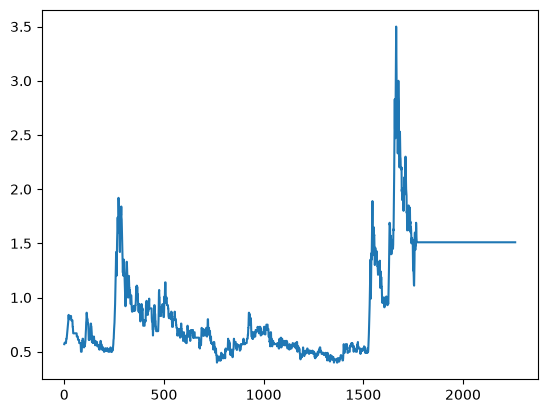

In [2]:
import matplotlib.pyplot as plt

plt.plot(unitybnk['close_price'])
plt.show()

In [3]:
unitybnk_end_month_df = (
    unitybnk
    .sort_values("date")
    .groupby(unitybnk["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

unitybnk_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45381,UNITYBNK,2017-01-31,0.78,0.78,236281.0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47203,UNITYBNK,2017-02-28,0.79,0.79,10000.0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49319,UNITYBNK,2017-03-31,0.64,0.64,50000.0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51147,UNITYBNK,2017-04-28,0.58,0.58,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53069,UNITYBNK,2017-05-31,0.56,0.56,577925.0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35387,UNITYBNK,2026-03-31,1.51,1.51,0.0,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281213,UNITYBNK,2026-04-30,1.51,1.51,NaN,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284279,UNITYBNK,2026-05-29,1.51,1.51,NaN,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294207,UNITYBNK,2026-06-30,1.51,1.51,NaN,2026-06-30T15:10:03.08168+00:00,6,2,2026


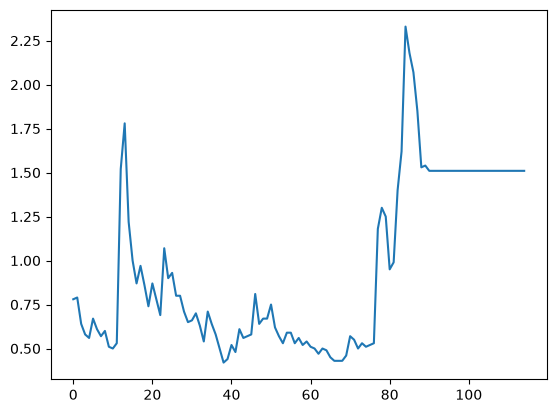

In [4]:
plt.plot(unitybnk_end_month_df['close_price'])
plt.show()

In [5]:
unitybnk_end_month_df['returns']=unitybnk_end_month_df['close_price'].pct_change()*100
unitybnk_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45381,UNITYBNK,2017-01-31,0.78,0.78,236281.0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47203,UNITYBNK,2017-02-28,0.79,0.79,10000.0,2026-04-08T02:44:45.006295+00:00,2,1,2017,1.282051
2,49319,UNITYBNK,2017-03-31,0.64,0.64,50000.0,2026-04-08T02:45:42.281198+00:00,3,1,2017,-18.987342
3,51147,UNITYBNK,2017-04-28,0.58,0.58,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017,-9.375000
4,53069,UNITYBNK,2017-05-31,0.56,0.56,577925.0,2026-04-08T02:52:57.421655+00:00,5,2,2017,-3.448276
...,...,...,...,...,...,...,...,...,...,...,...
110,35387,UNITYBNK,2026-03-31,1.51,1.51,0.0,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281213,UNITYBNK,2026-04-30,1.51,1.51,NaN,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.000000
112,284279,UNITYBNK,2026-05-29,1.51,1.51,NaN,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294207,UNITYBNK,2026-06-30,1.51,1.51,NaN,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


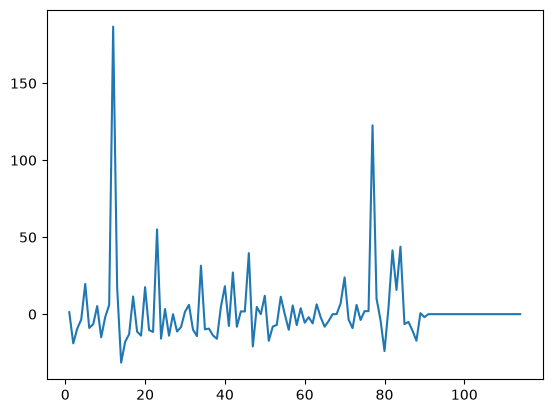

In [6]:
plt.plot(unitybnk_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(unitybnk_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.100048547200764), np.float64(1.0653935788060552e-17), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(865.2025966165546))
stationary


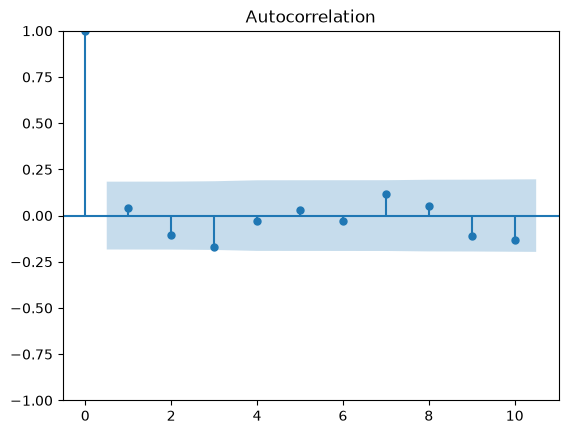

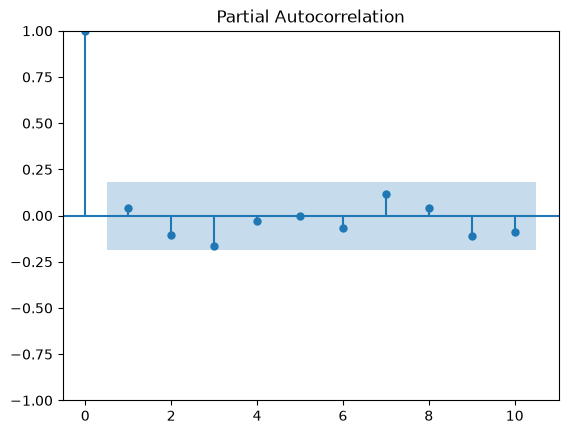

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(unitybnk_end_month_df['returns'].dropna(), lags=10)
plot_pacf(unitybnk_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=unitybnk_end_month_df['close_price'][:-10]
test=unitybnk_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, 0.0]
[0, 0, 0, 0, 0, 1, 0.0]
[0, 0, 0, 0, 0, 2, 0.0]
[0, 0, 0, 0, 1, 0, 0.0]
[0, 0, 0, 0, 1, 1, 0.0]
[0, 0, 0, 0, 1, 2, 0.0]
[0, 0, 0, 0, 2, 0, 0.0]
[0, 0, 0, 0, 2, 1, 0.0]
[0, 0, 0, 0, 2, 2, 0.0]
[0, 0, 0, 1, 0, 0, 0.0]
[0, 0, 0, 1, 0, 1, 0.0]
[0, 0, 0, 1, 0, 2, 0.0]
[0, 0, 0, 1, 1, 0, 0.0]
[0, 0, 0, 1, 1, 1, 0.0]
[0, 0, 0, 1, 1, 2, 0.0]
[0, 0, 0, 1, 2, 0, 0.0]
[0, 0, 0, 1, 2, 1, 0.0]
[0, 0, 0, 1, 2, 2, 0.0]
[0, 0, 0, 2, 0, 0, 0.0]
[0, 0, 0, 2, 0, 1, 0.0]
[0, 0, 0, 2, 0, 2, 0.0]
[0, 0, 0, 2, 1, 0, 0.0]
[0, 0, 0, 2, 1, 1, 0.0]
[0, 0, 0, 2, 1, 2, 0.0]
[0, 0, 0, 2, 2, 0, 0.0]
[0, 0, 0, 2, 2, 1, 0.0]
[0, 0, 0, 2, 2, 2, 0.0]
[0, 0, 1, 0, 0, 0, 0.0]
[0, 0, 1, 0, 0, 1, 0.0]
[0, 0, 1, 0, 0, 2, 0.0]
[0, 0, 1, 0, 1, 0, 0.0]
[0, 0, 1, 0, 1, 1, 0.0]
[0, 0, 1, 0, 1, 2, 0.0]
[0, 0, 1, 0, 2, 0, 0.0]
[0, 0, 1, 0, 2, 1, 0.0]
[0, 0, 1, 0, 2, 2, 0.0]
[0, 0, 1, 1, 0, 0, 0.0]
[0, 0, 1, 1, 0, 1, 0.0]
[0, 0, 1, 1, 0, 2, 0.0]
[0, 0, 1, 1, 1, 0, 0.0]
[0, 0, 1, 1, 1, 1, 0.0]
[0, 0, 1, 1, 1, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
15,0,0,0,1,2,0,0.0
1,0,0,0,0,0,1,0.0
2,0,0,0,0,0,2,0.0
3,0,0,0,0,1,0,0.0
4,0,0,0,0,1,1,0.0
...,...,...,...,...,...,...,...
576,2,1,0,1,0,0,1.0
567,2,1,0,0,0,0,1.0
405,1,2,0,0,0,0,1.0
414,1,2,0,1,0,0,1.0


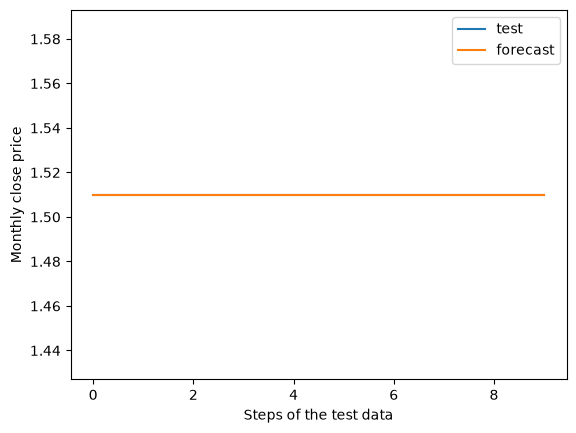

r2_score:  1.0
rmse:  0.0
description:  count    115.000000
mean       0.943913
std        0.473169
min        0.420000
25%        0.555000
50%        0.710000
75%        1.510000
max        2.330000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=unitybnk_end_month_df['close_price'][:-10]
y_test=unitybnk_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', unitybnk_end_month_df.close_price.describe())

Its not capturing the variations properly.